# Advanced Monte Carlo Methods Tutorial

This tutorial demonstrates the advanced numerical methods implemented in QuantStrata Phase 4.2:

1. **Longstaff-Schwartz (LSM)** - American option pricing via regression
2. **Quasi-Monte Carlo (QMC)** - Faster convergence with Sobol sequences
3. **Importance Sampling** - Variance reduction for OTM options

---

In [1]:
# Standard imports
import sys
sys.path.insert(0, '../../..')

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

## 1. Longstaff-Schwartz for American Options

The LSM algorithm prices American options by combining Monte Carlo simulation with regression to estimate continuation values.

In [2]:
from src.models.numeric.monte_carlo.lsm import (
    price_american_put_lsm,
    price_american_call_lsm,
    BasisType,
)

# Price an American put
result = price_american_put_lsm(
    spot0=100.0,
    strike=100.0,
    maturity=1.0,
    r=0.05,
    sigma=0.2,
    n_paths=100000,
    n_steps=50,
    seed=42,
)

print(f"American Put Price: {result.price:.4f}")
print(f"Standard Error: {result.std_error:.4f}")
print(f"95% Confidence Interval: {result.confidence_interval_95}")

American Put Price: 6.0629
Standard Error: 0.0229
95% Confidence Interval: (6.017976658294294, 6.107770724103214)


### 1.1 Early Exercise Premium

American puts have value above their European counterparts due to early exercise.

In [3]:
def bs_european_put(S, K, T, r, sigma):
    """Black-Scholes European put price."""
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

# Parameters
S0, K, T, r, sigma = 100.0, 100.0, 1.0, 0.05, 0.2

# European put (Black-Scholes)
european_put = bs_european_put(S0, K, T, r, sigma)

# American put (LSM)
american_result = price_american_put_lsm(
    spot0=S0, strike=K, maturity=T, r=r, sigma=sigma,
    n_paths=200000, n_steps=100, seed=42
)

premium = american_result.price - european_put

print(f"European Put (BS): {european_put:.4f}")
print(f"American Put (LSM): {american_result.price:.4f}")
print(f"Early Exercise Premium: {premium:.4f} ({premium/european_put*100:.1f}%)")

European Put (BS): 5.5735
American Put (LSM): 6.0575
Early Exercise Premium: 0.4840 (8.7%)


### 1.2 Exercise Boundary Visualization

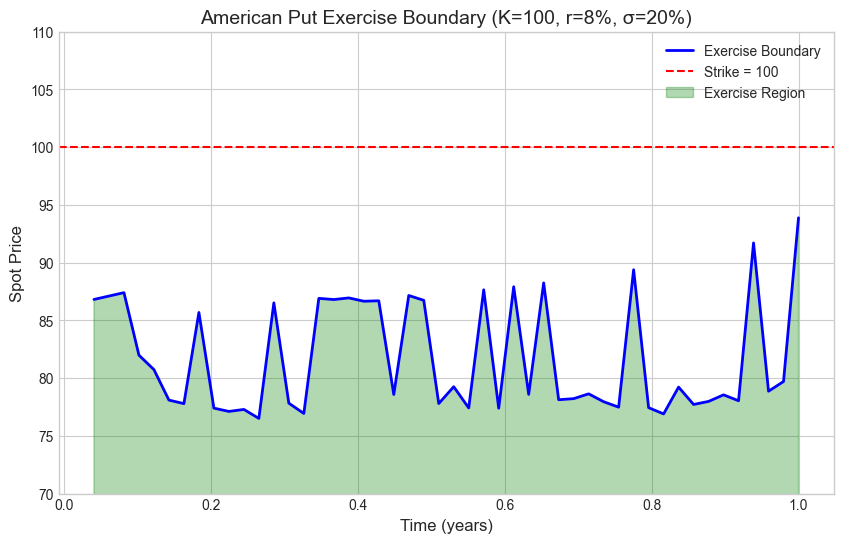

In [4]:
# Get detailed result with exercise boundary
result = price_american_put_lsm(
    spot0=100, strike=100, maturity=1.0, r=0.08, sigma=0.2,
    n_paths=100000, n_steps=50, seed=42
)

# Extract exercise boundary
time_grid = np.linspace(0, 1.0, len(result.exercise_boundary))
valid_mask = ~np.isnan(result.exercise_boundary)

plt.figure(figsize=(10, 6))
plt.plot(time_grid[valid_mask], result.exercise_boundary[valid_mask], 
         'b-', linewidth=2, label='Exercise Boundary')
plt.axhline(y=100, color='r', linestyle='--', label='Strike = 100')
plt.fill_between(time_grid[valid_mask], 0, result.exercise_boundary[valid_mask], 
                 alpha=0.3, color='green', label='Exercise Region')
plt.xlabel('Time (years)', fontsize=12)
plt.ylabel('Spot Price', fontsize=12)
plt.title('American Put Exercise Boundary (K=100, r=8%, σ=20%)', fontsize=14)
plt.legend()
plt.ylim(70, 110)
plt.grid(True)
plt.show()

### 1.3 Early Exercise Premium by Interest Rate

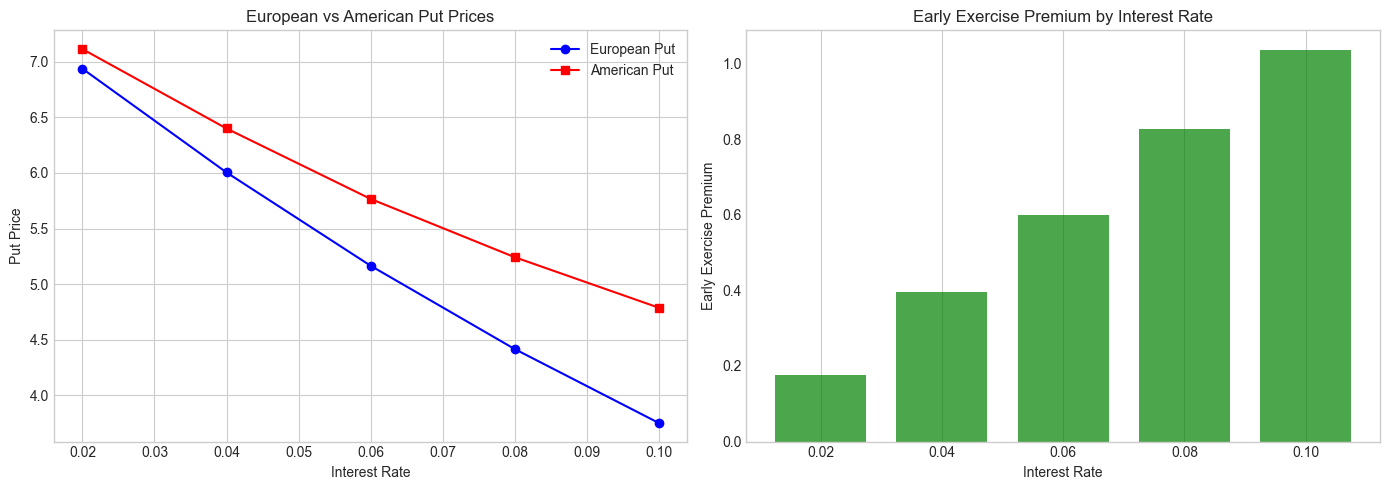

In [5]:
# Higher interest rates increase early exercise premium for puts
rates = [0.02, 0.04, 0.06, 0.08, 0.10]
european_prices = []
american_prices = []
premiums = []

for r in rates:
    eu = bs_european_put(100, 100, 1.0, r, 0.2)
    am = price_american_put_lsm(
        spot0=100, strike=100, maturity=1.0, r=r, sigma=0.2,
        n_paths=50000, n_steps=50, seed=42
    ).price
    european_prices.append(eu)
    american_prices.append(am)
    premiums.append(am - eu)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prices
axes[0].plot(rates, european_prices, 'b-o', label='European Put')
axes[0].plot(rates, american_prices, 'r-s', label='American Put')
axes[0].set_xlabel('Interest Rate')
axes[0].set_ylabel('Put Price')
axes[0].set_title('European vs American Put Prices')
axes[0].legend()
axes[0].grid(True)

# Premium
axes[1].bar(rates, premiums, width=0.015, color='green', alpha=0.7)
axes[1].set_xlabel('Interest Rate')
axes[1].set_ylabel('Early Exercise Premium')
axes[1].set_title('Early Exercise Premium by Interest Rate')
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

---

## 2. Quasi-Monte Carlo (QMC)

QMC uses low-discrepancy sequences (like Sobol) that fill the sample space more uniformly, providing faster convergence.

In [6]:
from src.models.numeric.monte_carlo.qmc import (
    SobolRng,
    qmc_european_call,
    qmc_european_put,
)

### 2.1 Visualizing Sobol vs Pseudo-Random

/Users/joesstevens/PycharmProjects/QuantStrata/docs/tutorials/pricing/../../../src/models/numeric/monte_carlo/qmc.py:97: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  return self._engine.random(n)
/var/folders/x6/k5s5xs4135d241wcn54pxjdh0000gn/T/ipykernel_23072/888494298.py:27: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/x6/k5s5xs4135d241wcn54pxjdh0000gn/T/ipykernel_23072/888494298.py:27: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/joesstevens/PycharmProjects/QuantStrata/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/joesstevens/PycharmProjects/QuantStrata/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.


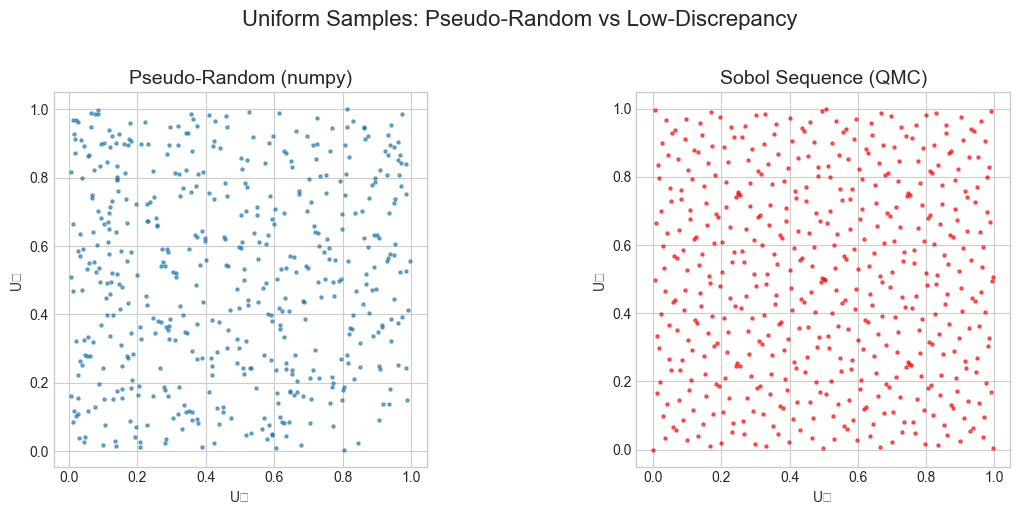

In [7]:
# Generate 2D samples
n_points = 500

# Pseudo-random
np.random.seed(42)
pseudo_random = np.random.rand(n_points, 2)

# Sobol (low-discrepancy)
sobol_rng = SobolRng(d=2, seed=42, scramble=False)
sobol_points = sobol_rng.uniform(n_points)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(pseudo_random[:, 0], pseudo_random[:, 1], s=5, alpha=0.6)
axes[0].set_title('Pseudo-Random (numpy)', fontsize=14)
axes[0].set_xlabel('U₁')
axes[0].set_ylabel('U₂')
axes[0].set_aspect('equal')

axes[1].scatter(sobol_points[:, 0], sobol_points[:, 1], s=5, alpha=0.6, c='red')
axes[1].set_title('Sobol Sequence (QMC)', fontsize=14)
axes[1].set_xlabel('U₁')
axes[1].set_ylabel('U₂')
axes[1].set_aspect('equal')

plt.suptitle('Uniform Samples: Pseudo-Random vs Low-Discrepancy', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 2.2 Convergence Comparison: MC vs QMC

True Black-Scholes Price: 9.227006


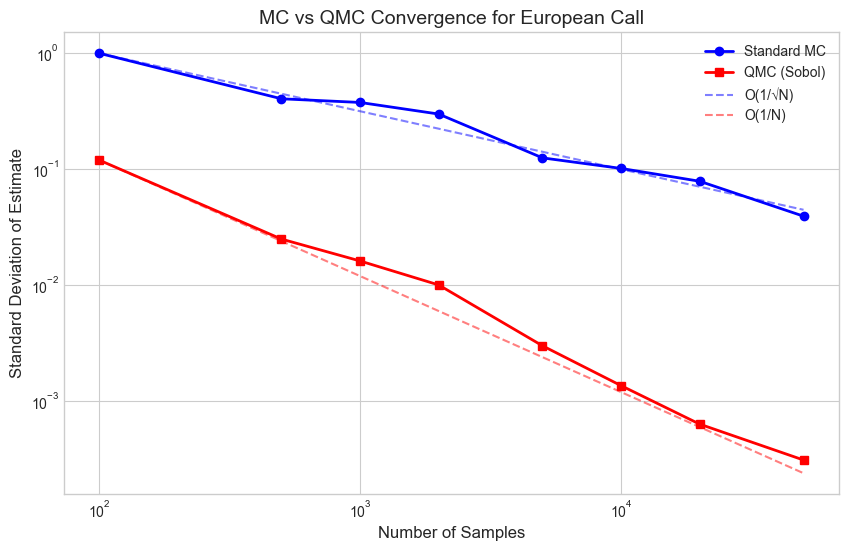

In [8]:
from src.models.numeric.monte_carlo.rng import NormalRng

# Parameters
S, K, T, r, q, sigma = 100, 100, 1.0, 0.05, 0.02, 0.2

# True price (Black-Scholes)
d1 = (np.log(S/K) + (r-q+0.5*sigma**2)*T) / (sigma*np.sqrt(T))
d2 = d1 - sigma*np.sqrt(T)
bs_price = S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
print(f"True Black-Scholes Price: {bs_price:.6f}")

# Convergence study
sample_sizes = [100, 500, 1000, 2000, 5000, 10000, 20000, 50000]
n_trials = 20

mc_errors = []
qmc_errors = []

for n in sample_sizes:
    mc_prices = []
    qmc_prices = []
    
    for trial in range(n_trials):
        seed = trial * 1000
        
        # Standard MC
        rng = NormalRng(seed=seed)
        Z = rng.standard_normals(n, 1, antithetic=True).flatten()
        ST = S * np.exp((r-q-0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
        mc_price = np.exp(-r*T) * np.maximum(ST - K, 0).mean()
        mc_prices.append(mc_price)
        
        # QMC
        qmc_price, _ = qmc_european_call(S, K, T, r, q, sigma, n, seed=seed)
        qmc_prices.append(qmc_price)
    
    mc_errors.append(np.std(mc_prices))
    qmc_errors.append(np.std(qmc_prices))

# Plot
plt.figure(figsize=(10, 6))
plt.loglog(sample_sizes, mc_errors, 'b-o', label='Standard MC', linewidth=2)
plt.loglog(sample_sizes, qmc_errors, 'r-s', label='QMC (Sobol)', linewidth=2)

# Reference lines
x = np.array(sample_sizes)
plt.loglog(x, mc_errors[0] * np.sqrt(sample_sizes[0]/x), 'b--', alpha=0.5, label='O(1/√N)')
plt.loglog(x, qmc_errors[0] * sample_sizes[0]/x, 'r--', alpha=0.5, label='O(1/N)')

plt.xlabel('Number of Samples', fontsize=12)
plt.ylabel('Standard Deviation of Estimate', fontsize=12)
plt.title('MC vs QMC Convergence for European Call', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)
plt.show()

### 2.3 QMC for European Options

In [9]:
# Price call and put
call_price, call_se = qmc_european_call(
    spot0=100, strike=105, maturity=0.5, r=0.05, q=0.02, sigma=0.2,
    n_samples=50000, seed=42
)

put_price, put_se = qmc_european_put(
    spot0=100, strike=95, maturity=0.5, r=0.05, q=0.02, sigma=0.2,
    n_samples=50000, seed=42
)

print(f"QMC European Call (K=105): {call_price:.4f} ± {call_se:.4f}")
print(f"QMC European Put (K=95):   {put_price:.4f} ± {put_se:.4f}")

QMC European Call (K=105): 4.1368 ± 0.0245
QMC European Put (K=95):   2.8085 ± 0.0167


---

## 3. Importance Sampling

Importance sampling reduces variance by oversampling "important" regions, particularly useful for deep OTM options.

In [10]:
from src.models.numeric.monte_carlo.importance_sampling import (
    is_european_put,
    is_european_call,
    compare_is_standard_mc,
    optimal_drift_shift_put,
)

### 3.1 Deep OTM Put: MC vs Importance Sampling

In [11]:
# Deep OTM put (S=100, K=70) - standard MC struggles here
comparison = compare_is_standard_mc(
    spot0=100,
    strike=70,
    maturity=1.0,
    r=0.05,
    q=0.02,
    sigma=0.2,
    n_samples=100000,
    seed=42,
)

print("=" * 55)
print(f"{'Black-Scholes Price:':<25} {comparison['bs_price']:.6f}")
print("-" * 55)
print(f"{'Standard MC Price:':<25} {comparison['mc_price']:.6f}")
print(f"{'Standard MC Std Error:':<25} {comparison['mc_std_error']:.6f}")
print(f"{'MC Absolute Error:':<25} {comparison['mc_error']:.6f}")
print("-" * 55)
print(f"{'IS Price:':<25} {comparison['is_price']:.6f}")
print(f"{'IS Std Error:':<25} {comparison['is_std_error']:.6f}")
print(f"{'IS Absolute Error:':<25} {comparison['is_error']:.6f}")
print("-" * 55)
print(f"{'Variance Reduction:':<25} {comparison['variance_reduction']:.1f}x")
print(f"{'Drift Shift Used:':<25} {comparison['drift_shift']:.3f}")
print("=" * 55)

Black-Scholes Price:      0.163069
-------------------------------------------------------
Standard MC Price:        0.165268
Standard MC Std Error:    0.003692
MC Absolute Error:        0.002199
-------------------------------------------------------
IS Price:                 0.162499
IS Std Error:             0.000592
IS Absolute Error:        0.000570
-------------------------------------------------------
Variance Reduction:       38.8x
Drift Shift Used:         -9.167


### 3.2 Variance Reduction by Moneyness

/var/folders/x6/k5s5xs4135d241wcn54pxjdh0000gn/T/ipykernel_23072/2858167305.py:34: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/joesstevens/PycharmProjects/QuantStrata/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


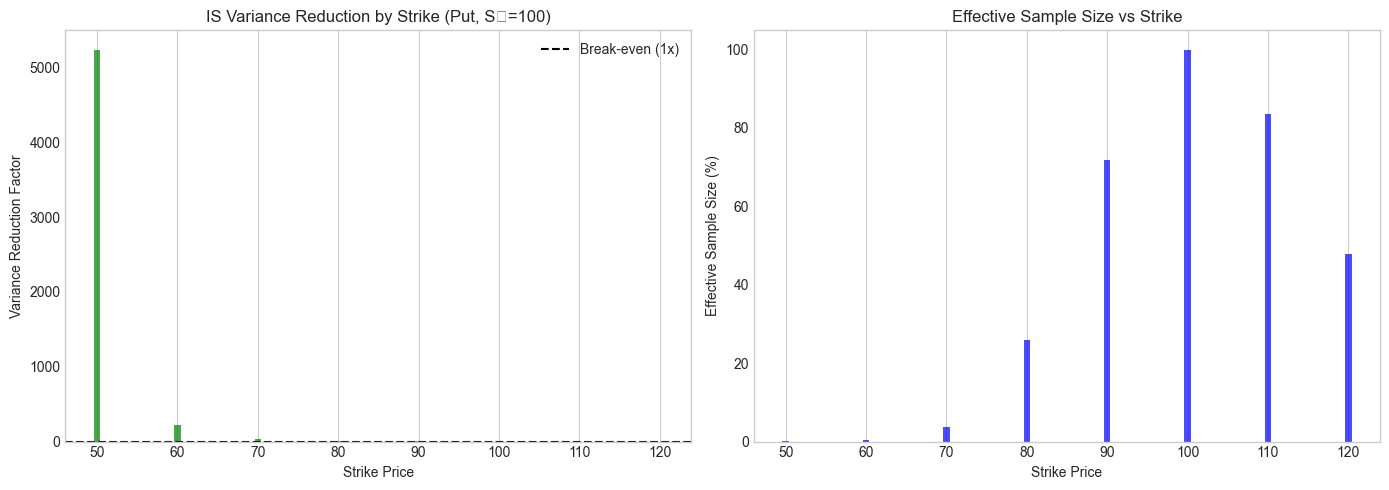

In [12]:
# Study variance reduction for different OTM levels
strikes = [50, 60, 70, 80, 90, 100, 110, 120]
variance_reductions = []
effective_sample_sizes = []

for K in strikes:
    result = is_european_put(
        spot0=100, strike=K, maturity=1.0, r=0.05, q=0.02, sigma=0.2,
        n_samples=50000, seed=42
    )
    variance_reductions.append(result.variance_reduction)
    effective_sample_sizes.append(result.effective_sample_size / result.n_samples * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variance reduction
moneyness = [(100 - K) / 100 * 100 for K in strikes]
colors = ['green' if vr > 1 else 'red' for vr in variance_reductions]
axes[0].bar(strikes, variance_reductions, color=colors, alpha=0.7)
axes[0].axhline(y=1, color='black', linestyle='--', label='Break-even (1x)')
axes[0].set_xlabel('Strike Price')
axes[0].set_ylabel('Variance Reduction Factor')
axes[0].set_title('IS Variance Reduction by Strike (Put, S₀=100)')
axes[0].legend()
axes[0].grid(axis='y')

# Effective sample size
axes[1].bar(strikes, effective_sample_sizes, color='blue', alpha=0.7)
axes[1].set_xlabel('Strike Price')
axes[1].set_ylabel('Effective Sample Size (%)')
axes[1].set_title('Effective Sample Size vs Strike')
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

### 3.3 Visualizing Importance Sampling

Optimal drift shift: θ = -9.167


/Users/joesstevens/PycharmProjects/QuantStrata/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8348 (\N{LATIN SUBSCRIPT SMALL LETTER T}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


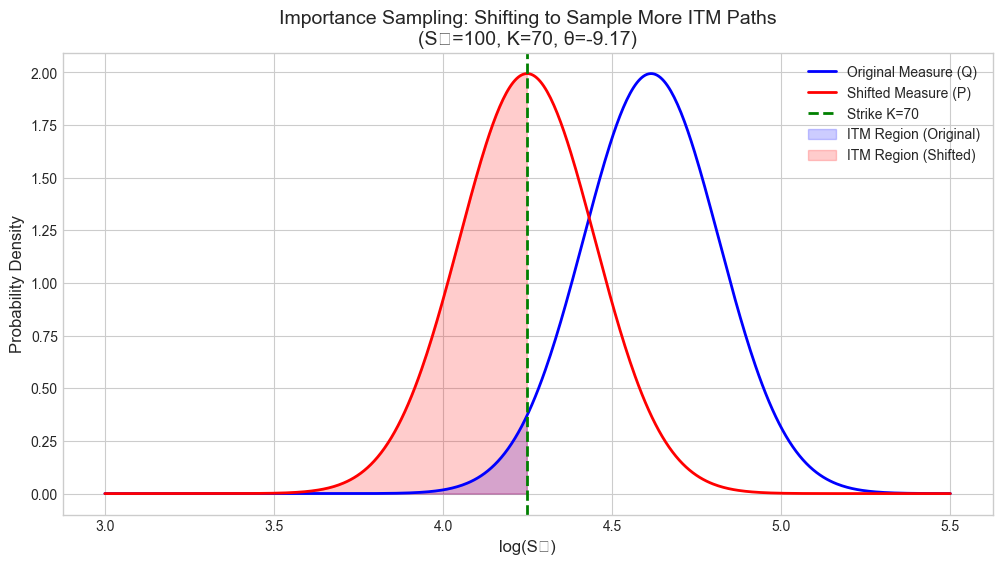

In [13]:
# Visualize the effect of drift shift
S0, K, T, r, q, sigma = 100, 70, 1.0, 0.05, 0.02, 0.2

# Normal distribution under original and shifted measure
drift = (r - q - 0.5 * sigma**2) * T
vol = sigma * np.sqrt(T)

theta = optimal_drift_shift_put(S0, K, T, r, q, sigma)
print(f"Optimal drift shift: θ = {theta:.3f}")

# Log-spot distribution
log_S0 = np.log(S0)
log_K = np.log(K)

x = np.linspace(3.0, 5.5, 500)

# Original distribution
mean_orig = log_S0 + drift
pdf_orig = norm.pdf(x, loc=mean_orig, scale=vol)

# Shifted distribution
mean_shifted = mean_orig + theta * vol**2
pdf_shifted = norm.pdf(x, loc=mean_shifted, scale=vol)

plt.figure(figsize=(12, 6))
plt.plot(x, pdf_orig, 'b-', linewidth=2, label='Original Measure (Q)')
plt.plot(x, pdf_shifted, 'r-', linewidth=2, label='Shifted Measure (P)')
plt.axvline(x=log_K, color='green', linestyle='--', linewidth=2, label=f'Strike K={K}')
plt.fill_between(x, 0, pdf_orig, where=x < log_K, alpha=0.2, color='blue', label='ITM Region (Original)')
plt.fill_between(x, 0, pdf_shifted, where=x < log_K, alpha=0.2, color='red', label='ITM Region (Shifted)')

plt.xlabel('log(Sₜ)', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title(f'Importance Sampling: Shifting to Sample More ITM Paths\n(S₀={S0}, K={K}, θ={theta:.2f})', fontsize=14)
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

---

## 4. Combining Methods

These methods can be combined for maximum efficiency.

### 4.1 QMC + LSM for American Options

In [14]:
from src.models.numeric.monte_carlo.qmc import qmc_path_simulation
from src.models.numeric.monte_carlo.lsm import lsm_american_put

# Generate paths with QMC
S0, K, T, r, sigma = 100, 100, 1.0, 0.05, 0.2
n_paths, n_steps = 50000, 50
dt = T / n_steps

# QMC paths
paths_qmc = qmc_path_simulation(
    spot0=S0, maturity=T, r=r, q=0, sigma=sigma,
    n_paths=n_paths, n_steps=n_steps, seed=42
)

# Standard MC paths
rng = NormalRng(seed=42)
Z = rng.standard_normals(n_paths, n_steps, antithetic=True)
paths_mc = np.zeros((Z.shape[0], n_steps + 1))
paths_mc[:, 0] = S0
for t in range(n_steps):
    paths_mc[:, t+1] = paths_mc[:, t] * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z[:, t])

# Price with LSM
result_qmc = lsm_american_put(paths_qmc, strike=K, r=r, dt=dt)
result_mc = lsm_american_put(paths_mc, strike=K, r=r, dt=dt)

print(f"LSM with QMC paths: {result_qmc.price:.4f} ± {result_qmc.std_error:.4f}")
print(f"LSM with MC paths:  {result_mc.price:.4f} ± {result_mc.std_error:.4f}")

LSM with QMC paths: 6.0929 ± 0.0326
LSM with MC paths:  6.0694 ± 0.0326


### 4.2 Method Selection Guide

In [15]:
# Summary table
print("""
╔═══════════════════════════════════════════════════════════════════════════╗
║                    Method Selection Guide                                  ║
╠═══════════════════════════════════════════════════════════════════════════╣
║ Method              │ Best For                    │ Convergence           ║
╠═══════════════════════════════════════════════════════════════════════════╣
║ Standard MC         │ General purpose, high dim   │ O(1/√N)               ║
║ QMC (Sobol)         │ Low dim, smooth payoffs     │ O(1/N)                ║
║ Importance Sampling │ Deep OTM, rare events       │ Varies (can be >>)    ║
║ LSM                 │ American options            │ O(1/√N) + regression  ║
║ Antithetic          │ Monotonic payoffs           │ Halves variance       ║
║ Control Variates    │ Known correlated variable   │ Reduces by ρ²         ║
╚═══════════════════════════════════════════════════════════════════════════╝

Recommended Combinations:
- European ATM/ITM:      Standard MC + Antithetic
- European OTM:          Importance Sampling + Antithetic  
- European low-dim:      QMC + Antithetic
- American options:      LSM + Antithetic (or QMC paths)
- Path-dependent:        Standard MC + Control Variates
""")


╔═══════════════════════════════════════════════════════════════════════════╗
║                    Method Selection Guide                                  ║
╠═══════════════════════════════════════════════════════════════════════════╣
║ Method              │ Best For                    │ Convergence           ║
╠═══════════════════════════════════════════════════════════════════════════╣
║ Standard MC         │ General purpose, high dim   │ O(1/√N)               ║
║ QMC (Sobol)         │ Low dim, smooth payoffs     │ O(1/N)                ║
║ Importance Sampling │ Deep OTM, rare events       │ Varies (can be >>)    ║
║ LSM                 │ American options            │ O(1/√N) + regression  ║
║ Antithetic          │ Monotonic payoffs           │ Halves variance       ║
║ Control Variates    │ Known correlated variable   │ Reduces by ρ²         ║
╚═══════════════════════════════════════════════════════════════════════════╝

Recommended Combinations:
- European ATM/ITM:      Standard M

---

## Summary

This tutorial demonstrated:

1. **LSM** - Pricing American options via regression, visualizing early exercise boundaries
2. **QMC** - Faster convergence with Sobol sequences for European options
3. **Importance Sampling** - Dramatic variance reduction for deep OTM options

Key takeaways:
- Use **LSM** for American/Bermudan exercise
- Use **QMC** for low-dimensional European options  
- Use **Importance Sampling** for tail risk and deep OTM pricing
- **Combine methods** for maximum efficiency

---

*QuantStrata Tutorial | Phase 4.2 | January 2026*